In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/duongquanganh/processed-data-v6/processed_val.csv
/kaggle/input/datasets/duongquanganh/processed-data-v6/processed_train.csv
/kaggle/input/datasets/duongquanganh/processed-data-v6/processed_test.csv


In [2]:
import csv

In [3]:
TRAIN_PATH = "/kaggle/input/datasets/duongquanganh/processed-data-v6/processed_train.csv"
VAL_PATH = "/kaggle/input/datasets/duongquanganh/processed-data-v6/processed_val.csv"
TEST_PATH = "/kaggle/input/datasets/duongquanganh/processed-data-v6/processed_test.csv"

In [4]:
def process(path):
    raw_reviews = []
    cleaned_reviews = []
    ws_reviews = []
    full_labels = []
    aspect_labels = []
    aspect_category_labels = []
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            raw_review = row.get("raw_reviews").strip()
            raw_reviews.append(raw_review)

            cleaned_review = row.get("cleaned_reviews").strip()
            cleaned_reviews.append(cleaned_review)

            ws_review = row.get("ws_reviews").strip()
            ws_reviews.append(ws_review)
            
            labels = row.get("full_labels").strip()
            full_labels.append(labels)

            review_aspects = row.get("aspect_labels").strip()
            review_aspect_categories = row.get("aspect_category_labels").strip()
            aspect_labels.append(review_aspects)
            aspect_category_labels.append(review_aspect_categories)

    return raw_reviews, cleaned_reviews, ws_reviews, full_labels, aspect_labels, aspect_category_labels

In [5]:
train_raw_reviews, train_cleaned_reviews, train_ws_reviews, train_labels, train_aspect_labels, train_aspect_category_labels = process(TRAIN_PATH)
val_raw_reviews, val_cleaned_reviews, val_ws_reviews, val_labels, val_aspect_labels, val_aspect_category_labels = process(VAL_PATH)
test_raw_reviews, test_cleaned_reviews, test_ws_reviews, test_labels, test_aspect_labels, test_aspect_category_labels = process(TEST_PATH)

len(train_raw_reviews), len(val_raw_reviews), len(test_raw_reviews)

(2961, 1290, 500)

In [6]:
!pip install -q transformers tqdm

In [7]:
import json
import math
import random
import re
from collections import OrderedDict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
MODEL_NAME = "vinai/phobert-base"
MAX_LENGTH = 256
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 9e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 140
PATIENCE = 140
WARMUP_RATIO = 0.0
THRESHOLD_ENTITY = 0.5
THRESHOLD_ASPECT = 0.5
LOSS_WEIGHTS = {"entity": 2.0, "aspect": 3.0, "polarity": 1.0}

OUTPUT_DIR = Path("/kaggle/working/hierarchical_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Device: cuda


In [8]:
REQUIRED_COLUMNS = ["raw_reviews", "cleaned_reviews", "ws_reviews", "full_labels", "aspect_labels", "aspect_category_labels"]

def validate_schema(path: str, required_columns: List[str]):
    df = pd.read_csv(path, encoding="utf-8-sig")
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return df

train_df_raw = validate_schema(TRAIN_PATH, REQUIRED_COLUMNS)
val_df_raw = validate_schema(VAL_PATH, REQUIRED_COLUMNS)
test_df_raw = validate_schema(TEST_PATH, REQUIRED_COLUMNS)

print("Schema OK")
print("Train/Val/Test:", len(train_df_raw), len(val_df_raw), len(test_df_raw))

def split_pipe_labels(value: str) -> List[str]:
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [x.strip() for x in text.split("|") if x.strip()]

FULL_LABEL_PATTERN = re.compile(r"\{\s*([^,{}]+)\s*,\s*([^{}]+?)\s*\}")

def parse_full_label(full_label: str) -> List[Tuple[str, str]]:
    if full_label is None or (isinstance(full_label, float) and math.isnan(full_label)):
        return []
    text = str(full_label).strip()
    if not text:
        return []
    pairs = []
    for aspect_category, sentiment in FULL_LABEL_PATTERN.findall(text):
        pairs.append((aspect_category.strip(), sentiment.strip().lower()))
    return pairs

def normalize_sentiment(label: str) -> str:
    s = (label or "").strip().lower()
    if s in {"positive", "negative", "neutral"}:
        return s
    return "neutral"

def debug_raw_label_quality(df: pd.DataFrame, split_name: str):
    empty_aspect_category = 0
    empty_aspect = 0
    empty_full = 0
    parse_failed = 0
    mismatch_non_empty = 0

    for _, row in df.iterrows():
        aspect_category_text = row.get("aspect_category_labels", "")
        aspect_text = row.get("aspect_labels", "")
        full_text = row.get("full_labels", "")

        ac_list = split_pipe_labels(aspect_category_text)
        a_list = split_pipe_labels(aspect_text)
        full_pairs = parse_full_label(full_text)
        full_cats = [ac for ac, _ in full_pairs]

        if not ac_list:
            empty_aspect_category += 1
        if not a_list:
            empty_aspect += 1
        if str(full_text).strip() == "":
            empty_full += 1
        if str(full_text).strip() != "" and len(full_pairs) == 0:
            parse_failed += 1
        if ac_list and full_cats:
            # Aspect categories present in full_label but missing from aspect_category_label column.
            miss = [x for x in full_cats if x not in ac_list]
            if miss:
                mismatch_non_empty += 1

    n = len(df)
    print(f"[{split_name}] empty aspect_category_label: {empty_aspect_category}/{n}")
    print(f"[{split_name}] empty aspect_label: {empty_aspect}/{n}")
    print(f"[{split_name}] empty full_label: {empty_full}/{n}")
    print(f"[{split_name}] full_label parse_failed (non-empty but no pair): {parse_failed}/{n}")
    print(f"[{split_name}] rows with mismatch between aspect_category_label and full_label: {mismatch_non_empty}/{n}")

debug_raw_label_quality(train_df_raw, "train")
debug_raw_label_quality(val_df_raw, "val")
debug_raw_label_quality(test_df_raw, "test")

Schema OK
Train/Val/Test: 2961 1290 500
[train] empty aspect_category_label: 0/2961
[train] empty aspect_label: 0/2961
[train] empty full_label: 0/2961
[train] full_label parse_failed (non-empty but no pair): 0/2961
[train] rows with mismatch between aspect_category_label and full_label: 0/2961
[val] empty aspect_category_label: 0/1290
[val] empty aspect_label: 0/1290
[val] empty full_label: 0/1290
[val] full_label parse_failed (non-empty but no pair): 0/1290
[val] rows with mismatch between aspect_category_label and full_label: 0/1290
[test] empty aspect_category_label: 0/500
[test] empty aspect_label: 0/500
[test] empty full_label: 0/500
[test] full_label parse_failed (non-empty but no pair): 0/500
[test] rows with mismatch between aspect_category_label and full_label: 0/500


Taxonomy frozen
num_aspects: 6
num_aspect_categories: 12
[train] unknown aspects in mapping: 0
[train] unknown aspect categories in mapping: 0
[val] unknown aspects in mapping: 0
[val] unknown aspect categories in mapping: 0
[test] unknown aspects in mapping: 0
[test] unknown aspect categories in mapping: 0
[train] Aspect Category positive rates:
  FOOD#QUALITY: rate=0.8977, support=2658
  FOOD#STYLE&OPTIONS: rate=0.5897, support=1746
  FOOD#PRICES: rate=0.4732, support=1401
  RESTAURANT#GENERAL: rate=0.2888, support=855
  SERVICE#GENERAL: rate=0.2685, support=795
  AMBIENCE#GENERAL: rate=0.2489, support=737
  LOCATION#GENERAL: rate=0.1260, support=373
  RESTAURANT#PRICES: rate=0.0888, support=263
  RESTAURANT#MISCELLANEOUS: rate=0.0510, support=151
  DRINKS#QUALITY: rate=0.0385, support=114
  DRINKS#PRICES: rate=0.0344, support=102
  DRINKS#STYLE&OPTIONS: rate=0.0344, support=102

[train] Entity/Aspect positive rates:
  FOOD: rate=0.9672, support=2864
  RESTAURANT: rate=0.3705, suppor

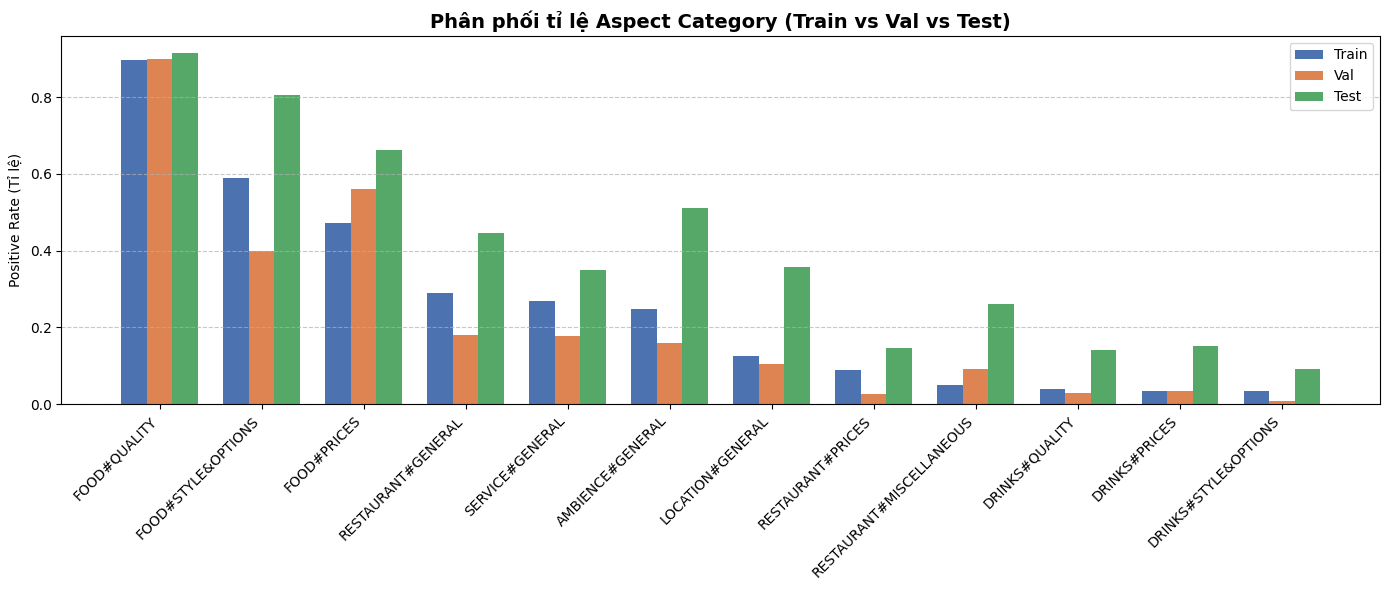

Đã lưu đồ thị thành công tại: entity_aspect_distribution.png


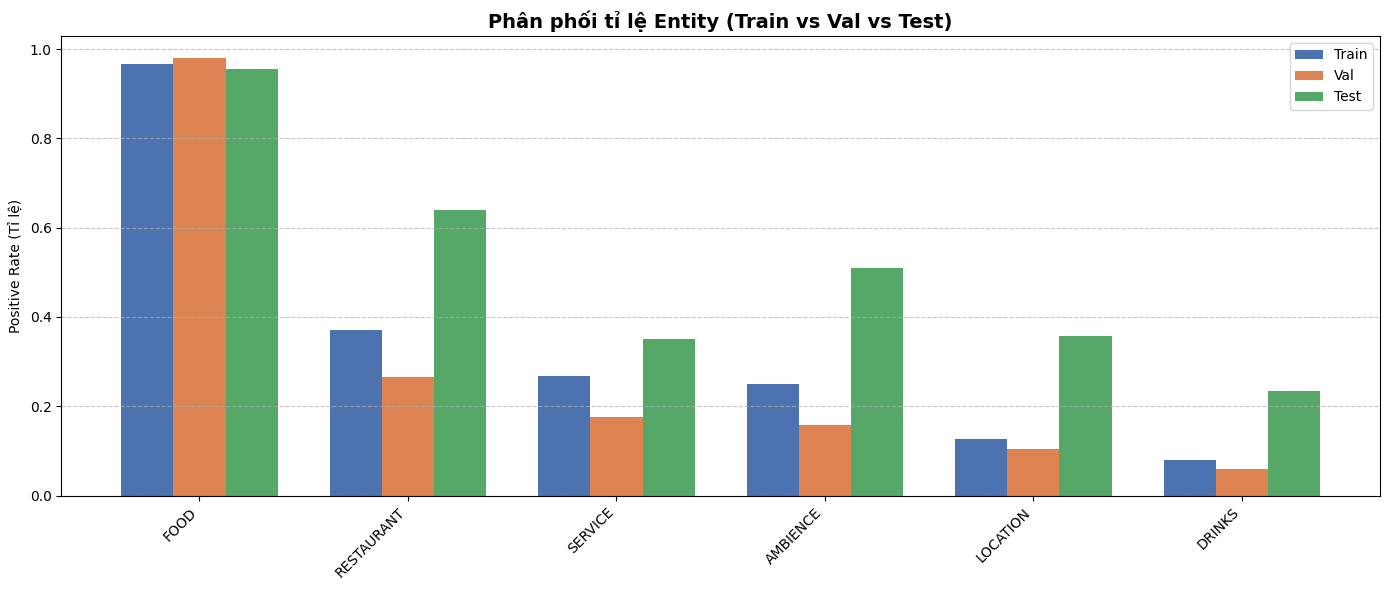

[train] Token length statistics (via Tokenizer):
  Min: 3
  Average: 61.63
  Max: 660
  % <= 256 tokens: 99.22% (2938/2961)
----------------------------------------
[val] Token length statistics (via Tokenizer):
  Min: 3
  Average: 56.28
  Max: 895
  % <= 256 tokens: 99.22% (1280/1290)
----------------------------------------
[test] Token length statistics (via Tokenizer):
  Min: 14
  Average: 181.46
  Max: 402
  % <= 256 tokens: 75.20% (376/500)
----------------------------------------
Đã lưu biểu đồ tại: /kaggle/working/hierarchical_outputs/token_distribution_vlsp2018.png


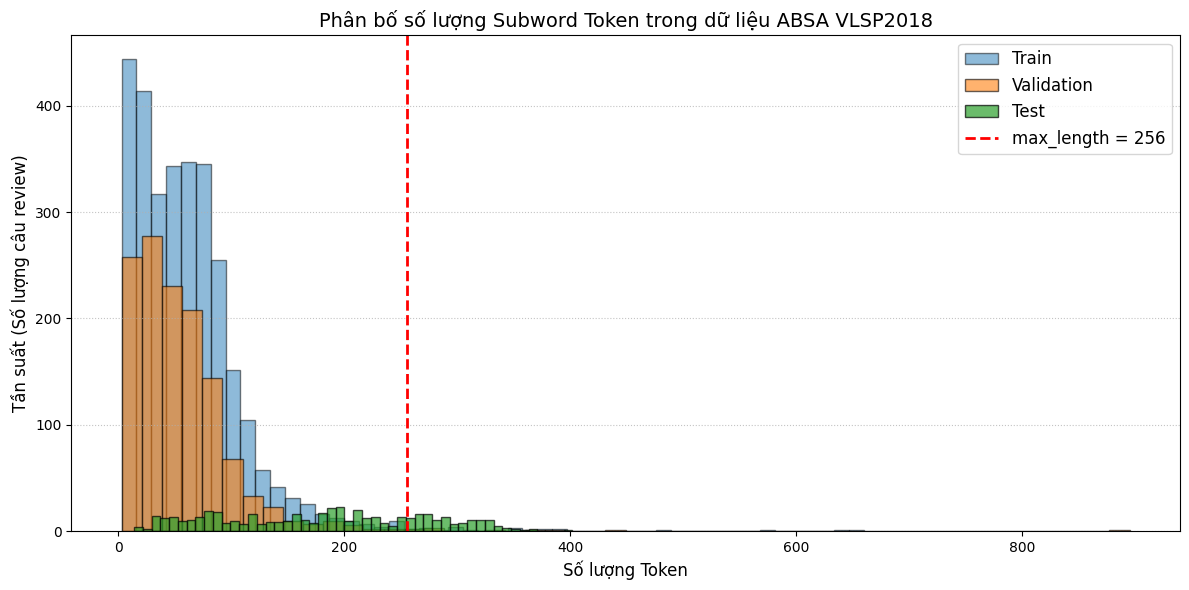

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

SENTIMENT_SPACE = ["negative", "neutral", "positive"]
sentiment2id = {s: i for i, s in enumerate(SENTIMENT_SPACE)}
id2sentiment = {i: s for s, i in sentiment2id.items()}

def build_records(df: pd.DataFrame) -> List[Dict]:
    records = []
    for _, row in df.iterrows():
        ws_review = str(row.get("ws_reviews", "") or "").strip()
        full_label = str(row.get("full_labels", "") or "").strip()
        aspect_text = row.get("aspect_labels", "")
        aspect_category_text = row.get("aspect_category_labels", "")

        full_pairs = parse_full_label(full_label)
        aspect_categories = split_pipe_labels(aspect_category_text)
        if not aspect_categories:
            aspect_categories = [ac for ac, _ in full_pairs]

        aspects = split_pipe_labels(aspect_text)
        if not aspects and aspect_categories:
            aspects = [ac.split("#", 1)[0] for ac in aspect_categories]

        polarity_by_aspect_category = OrderedDict()
        for ac, pol in full_pairs:
            polarity_by_aspect_category[ac] = normalize_sentiment(pol)

        records.append({
            "ws_review": ws_review,
            "full_label": full_label,
            "aspects": list(OrderedDict.fromkeys(aspects)),
            "aspect_categories": list(OrderedDict.fromkeys(aspect_categories)),
            "polarity_by_aspect_category": polarity_by_aspect_category,
        })
    return records

train_records = build_records(train_df_raw)
val_records = build_records(val_df_raw)
test_records = build_records(test_df_raw)

all_records = train_records + val_records + test_records
all_aspects = sorted({a for r in all_records for a in r["aspects"] if a})
all_aspect_categories = sorted({ac for r in all_records for ac in r["aspect_categories"] if ac})

aspect2id = {a: i for i, a in enumerate(all_aspects)}
id2aspect = {i: a for a, i in aspect2id.items()}
aspect_category2id = {ac: i for i, ac in enumerate(all_aspect_categories)}
id2aspect_category = {i: ac for ac, i in aspect_category2id.items()}

taxonomy = {
    "aspects": all_aspects,
    "aspect_categories": all_aspect_categories,
    "sentiments": SENTIMENT_SPACE,
    "aspect2id": aspect2id,
    "aspect_category2id": aspect_category2id,
    "sentiment2id": sentiment2id,
}

with open(OUTPUT_DIR / "taxonomy.json", "w", encoding="utf-8") as f:
    json.dump(taxonomy, f, ensure_ascii=False, indent=2)

print("Taxonomy frozen")
print("num_aspects:", len(all_aspects))
print("num_aspect_categories:", len(all_aspect_categories))

def debug_mapping_consistency(records: List[Dict], split_name: str):
    unknown_aspects = 0
    unknown_aspect_categories = 0
    for rec in records:
        for a in rec["aspects"]:
            if a not in aspect2id:
                unknown_aspects += 1
        for ac in rec["aspect_categories"]:
            if ac not in aspect_category2id:
                unknown_aspect_categories += 1
    print(f"[{split_name}] unknown aspects in mapping: {unknown_aspects}")
    print(f"[{split_name}] unknown aspect categories in mapping: {unknown_aspect_categories}")

def debug_label_distribution(records: List[Dict], split_name: str):
    n = len(records)
    
    cat_count = {ac: 0 for ac in all_aspect_categories}
    ent_count = {a: 0 for a in all_aspects}

    for rec in records:
        for ac in rec.get("aspect_categories", []):
            if ac in cat_count:
                cat_count[ac] += 1
        for a in rec.get("aspects", []):
            if a in ent_count:
                ent_count[a] += 1

    cat_rate = {k: (v / (n + 1e-9)) for k, v in cat_count.items()}
    ent_rate = {k: (v / (n + 1e-9)) for k, v in ent_count.items()}

    all_cat = sorted(cat_rate.items(), key=lambda x: x[1], reverse=True)
    all_ent = sorted(ent_rate.items(), key=lambda x: x[1], reverse=True)
    
    zero_cat = [k for k, v in cat_count.items() if v == 0]
    zero_ent = [k for k, v in ent_count.items() if v == 0]

    print(f"[{split_name}] Aspect Category positive rates:")
    for k, v in all_cat:
        print(f"  {k}: rate={v:.4f}, support={cat_count[k]}")

    print(f"\n[{split_name}] Entity/Aspect positive rates:")
    for k, v in all_ent:
        print(f"  {k}: rate={v:.4f}, support={ent_count[k]}")

    print(f"\n[{split_name}] Aspect_category with zero support: {len(zero_cat)}")
    if zero_cat:
        print(f"  Danh sách: {', '.join(zero_cat)}")
        
    print(f"[{split_name}] Entity with zero support: {len(zero_ent)}")
    if zero_ent:
        print(f"  Danh sách: {', '.join(zero_ent)}")
    print("-" * 50)
    return cat_rate, ent_rate

def plot_grouped_bar_chart(train_rates: Dict, val_rates: Dict, test_rates: Dict, title: str, save_path: str = None):
    # Lấy danh sách các nhãn (labels) và sắp xếp theo tỉ lệ giảm dần của tập Train
    labels = sorted(train_rates.keys(), key=lambda x: train_rates[x], reverse=True)
    
    # Lấy giá trị tương ứng cho từng tập
    train_vals = [train_rates.get(label, 0) for label in labels]
    val_vals = [val_rates.get(label, 0) for label in labels]
    test_vals = [test_rates.get(label, 0) for label in labels]

    x = np.arange(len(labels))  # Vị trí của các nhãn trên trục X
    width = 0.25                # Độ rộng của mỗi cột

    fig, ax = plt.subplots(figsize=(14, 6)) # Kích thước biểu đồ

    # Vẽ 3 cột đứng cạnh nhau
    rects1 = ax.bar(x - width, train_vals, width, label='Train', color='#4C72B0')
    rects2 = ax.bar(x, val_vals, width, label='Val', color='#DD8452')
    rects3 = ax.bar(x + width, test_vals, width, label='Test', color='#55A868')

    # Thêm thông tin cho biểu đồ
    ax.set_ylabel('Positive Rate (Tỉ lệ)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.tight_layout()
    
    # LƯU ẢNH TRƯỚC KHI SHOW
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Đã lưu đồ thị thành công tại: {save_path}")
        
    plt.show()

def debug_token_statistics(records: List[Dict], split_name: str, tokenizer) -> List[int]:
    if not records:
        print(f"[{split_name}] No records to evaluate.")
        return []
        
    token_counts = []
    for rec in records:
        text = rec.get("ws_review", "")
        if text:
            # Mã hóa qua subword tokenizer để lấy số lượng token thực tế
            token_ids = tokenizer.encode(text, add_special_tokens=True)
            token_counts.append(len(token_ids))
    
    if not token_counts:
        print(f"[{split_name}] No valid review text found.")
        return []
        
    min_tokens = min(token_counts)
    max_tokens = max(token_counts)
    avg_tokens = sum(token_counts) / len(token_counts)
    
    # Thống kê tỷ lệ câu có độ dài <= 256 tokens
    threshold = 256
    count_under_threshold = sum(1 for cnt in token_counts if cnt <= threshold)
    percent_under_threshold = (count_under_threshold / len(token_counts)) * 100
    
    print(f"[{split_name}] Token length statistics (via Tokenizer):")
    print(f"  Min: {min_tokens}")
    print(f"  Average: {avg_tokens:.2f}")
    print(f"  Max: {max_tokens}")
    print(f"  % <= {threshold} tokens: {percent_under_threshold:.2f}% ({count_under_threshold}/{len(token_counts)})")
    print("-" * 40)
    
    return token_counts

def plot_token_distribution(train_counts: List[int], val_counts: List[int], test_counts: List[int], output_dir: str = "."):
    """Vẽ biểu đồ cột (histogram) thể hiện phân bố độ dài token cho 3 tập dữ liệu."""
    plt.figure(figsize=(12, 6))

    bins = 50
    plt.hist(train_counts, bins=bins, alpha=0.5, label='Train', color='#1f77b4', edgecolor='black')
    plt.hist(val_counts, bins=bins, alpha=0.6, label='Validation', color='#ff7f0e', edgecolor='black')
    plt.hist(test_counts, bins=bins, alpha=0.7, label='Test', color='#2ca02c', edgecolor='black')
    
    plt.axvline(x=256, color='red', linestyle='--', linewidth=2, label='max_length = 256')
    
    plt.title("Phân bố số lượng Subword Token trong dữ liệu ABSA VLSP2018", fontsize=14)
    plt.xlabel("Số lượng Token", fontsize=12)
    plt.ylabel("Tần suất (Số lượng câu review)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.75, linestyle=':')
    
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, "token_distribution_vlsp2018.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã lưu biểu đồ tại: {save_path}")
    
    plt.show()

debug_mapping_consistency(train_records, "train")
debug_mapping_consistency(val_records, "val")
debug_mapping_consistency(test_records, "test")

cat_rate_train, ent_rate_train = debug_label_distribution(train_records, "train")
cat_rate_val, ent_rate_val = debug_label_distribution(val_records, "val")
cat_rate_test, ent_rate_test = debug_label_distribution(test_records, "test")

plot_grouped_bar_chart(
    cat_rate_train, cat_rate_val, cat_rate_test, 
    "Phân phối tỉ lệ Aspect Category (Train vs Val vs Test)",
    save_path="aspect_category_distribution.png"
)

plot_grouped_bar_chart(
    ent_rate_train, ent_rate_val, ent_rate_test, 
    "Phân phối tỉ lệ Entity (Train vs Val vs Test)",
    save_path="entity_aspect_distribution.png"
)

train_counts = debug_token_statistics(train_records, "train", tokenizer)
val_counts = debug_token_statistics(val_records, "val", tokenizer)
test_counts = debug_token_statistics(test_records, "test", tokenizer)

plot_token_distribution(train_counts, val_counts, test_counts, output_dir=str(OUTPUT_DIR))